# Notebook 2 — Consumo / eco-driving: `maf_per_km` sul tratto in arrivo (solo ICE)

**Ruolo nel progetto:** modello **supervised di consumo**. Predice la massa d'aria **per km su un
segmento di strada** (~250 m) da feature note in anticipo a un assistente di guida — *"quanto costa
il tratto che ho davanti, dato come penso di guidarlo?"*.

**Due scelte che definiscono questo notebook:**

1. **Perche' il segmento e non l'istante.** Un primo tentativo (ora abbandonato) predisse il MAF
   *istantaneo*: ma e' quasi una **tautologia fisica** (il MAF segue la richiesta motore del
   momento), la pendenza istantanea e' rumore, e il controfattuale eco/sport e' un artificio.
   Passando al **segmento** il target diventa `maf_per_km` (efficienza, non distanza banale) e si
   possono aggiungere feature di **anticipazione** (`entry_speed`, look-ahead del tratto dopo).

2. **Perche' solo ICE.** Il MAF (massa d'aria ~ carburante) e' un proxy di consumo valido **solo
   per i motori termici**. Su HEV/PHEV il motore si spegne in marcia (~21-24% del tempo, trazione
   elettrica) -> MAF=0 mentre il veicolo consuma energia (batteria), che il VED **non misura**.
   Mettere i tre powertrain in un unico modello di MAF mischia target incompatibili. Quindi qui
   restiamo agli **ICE** (~10,4M righe, il 58% del dataset). I tre powertrain vengono confrontati a
   parte nel NB3.

**Principio map-only:** solo feature note in anticipo; esclusi `Engine_RPM_RPM`/`Absolute_Load_pct`
(output del motore, non noti a priori). `EngineType` non e' piu' feature: ora e' costante (ICE).

**Tecniche del corso:** Pipeline + ColumnTransformer, Ridge/Lasso, Random Forest, XGBoost, split
temporale per trip, GroupKFold, Optuna, MAE/RMSE/R2, feature importance.

**Input:** `outputs/ved_enriched.parquet`.

## 1. Setup e caricamento (filtro ICE)

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
RANDOM_STATE = 42

DATA = Path("./outputs/ved_enriched.parquet")
df = pd.read_parquet(DATA)
print(f"Shape totale: {df.shape}")

# --- FILTRO SOLO ICE: MAF e' un proxy di consumo valido solo per i termici ---
df = df[df['EngineType'] == 'ICE'].reset_index(drop=True)
print(f"Shape solo-ICE: {df.shape}  ({df['VehId'].nunique()} veicoli)")

Shape totale: (17922869, 21)
Shape solo-ICE: (10401317, 21)  (197 veicoli)


## 2. Parametri e helper per la segmentazione

`SEG_LEN` (metri per segmento) governa la granularita'. **Perche' 250 m e non meno?** Sotto la
risoluzione SRTM (~30 m) il dislivello e' rumore; col sampling irregolare un segmento troppo corto
ha pochi punti e un `maf_per_km` instabile; e piu' si rimpicciolisce, piu' si torna alla predizione
*istantanea*. 250 m e' sopra il rumore ma abbastanza fine per l'anticipazione. Lo verifichiamo
empiricamente (sensibilita' a `SEG_LEN`).

In [14]:
SEG_LEN = 250
MIN_SEG_FRAC = 0.5
MIN_POINTS = 4
DT_CLIP_S = 2.0

df = df.sort_values(['VehId', 'Trip', 'Timestampms']).reset_index(drop=True)
df['dist_m'] = df['dist_m'].fillna(0.0)
df['dt_ms']  = df['dt_ms'].fillna(0.0)
df['dt_s_clip'] = (df['dt_ms'] / 1000.0).clip(lower=0, upper=DT_CLIP_S)
df['air_g'] = df['MAF_g_per_sec'] * df['dt_s_clip']
elev_diff = df.groupby(['VehId', 'Trip'])['elevation_m'].diff().fillna(0.0)
df['climb_row']   = elev_diff.clip(lower=0)
df['descent_row'] = (-elev_diff).clip(lower=0)
df['accel_abs'] = df['accel_kmh_s'].abs()
df['is_stop']   = (df['Vehicle_Speed_km_per_h'] < 2).astype(float)
df['hour']  = df['Datetime'].dt.hour
df['month'] = df['Datetime'].dt.month
print("Helper di riga pronti.")

Helper di riga pronti.


## 3. Costruzione dei segmenti

Dentro ogni trip accumuliamo la distanza e tagliamo un segmento ogni `SEG_LEN` metri. Aggreghiamo le
righe nelle feature note in anticipo (geometria + profilo di velocita') e nel target `maf_per_km`.

In [15]:
SEG_KEYS = ['VehId', 'Trip', 'seg_in_trip']

def build_segments(d, seg_len):
    # Aggrega le righe in segmenti da seg_len metri.
    d = d.copy()
    d['cum_dist'] = d.groupby(['VehId', 'Trip'])['dist_m'].cumsum()
    d['seg_in_trip'] = (d['cum_dist'] // seg_len).astype(int)
    seg = d.groupby(SEG_KEYS, sort=True).agg(
        n_points=('MAF_g_per_sec', 'size'),
        seg_distance_m=('dist_m', 'sum'),
        seg_time_s=('dt_s_clip', 'sum'),
        air_total_g=('air_g', 'sum'),
        elev_start=('elevation_m', 'first'),
        elev_end=('elevation_m', 'last'),
        climb_m=('climb_row', 'sum'),
        descent_m=('descent_row', 'sum'),
        slope_mean=('slope', 'mean'),
        slope_max_abs=('slope', lambda s: s.abs().max()),
        speed_mean=('Vehicle_Speed_km_per_h', 'mean'),
        speed_max=('Vehicle_Speed_km_per_h', 'max'),
        speed_min=('Vehicle_Speed_km_per_h', 'min'),
        speed_std=('Vehicle_Speed_km_per_h', 'std'),
        entry_speed=('Vehicle_Speed_km_per_h', 'first'),
        accel_abs_mean=('accel_abs', 'mean'),
        stop_fraction=('is_stop', 'mean'),
        OAT_DegC=('OAT_DegC', 'mean'),
        Generalized_Weight=('Generalized_Weight', 'first'),
        hour=('hour', 'first'),
        month=('month', 'first'),
        Datetime=('Datetime', 'first'),
    ).reset_index()
    seg['dz_net'] = seg['elev_end'] - seg['elev_start']
    seg['speed_std'] = seg['speed_std'].fillna(0.0)
    seg['maf_per_km'] = seg['air_total_g'] / (seg['seg_distance_m'] / 1000.0)
    seg = seg[(seg['seg_distance_m'] >= MIN_SEG_FRAC * seg_len) &
              (seg['n_points'] >= MIN_POINTS) &
              np.isfinite(seg['maf_per_km'])].reset_index(drop=True)
    return seg

seg = build_segments(df, SEG_LEN)
print(f"Segmenti (SEG_LEN={SEG_LEN} m): {len(seg):,} | trip: {seg.groupby(['VehId','Trip']).ngroups:,}")
print(seg[['seg_distance_m','speed_mean','dz_net','climb_m','maf_per_km']].describe().round(2))

Segmenti (SEG_LEN=250 m): 299,655 | trip: 14,676
       seg_distance_m  speed_mean     dz_net    climb_m  maf_per_km
count       299655.00   299655.00  299655.00  299655.00   299655.00
mean           248.76       56.58      -0.09      16.11     1064.77
std             62.30       27.48      18.83      17.05      855.26
min            125.01        0.00     -94.00       0.00        0.00
25%            230.64       38.18      -8.00       2.00      563.09
50%            248.39       55.58       0.00      10.00      865.84
75%            265.79       68.53       8.00      26.00     1347.22
max           9203.59      169.91      81.00     211.00    84575.82


## 4. Feature di accoppiamento — l'**anticipazione**

Un modello che vede solo il proprio segmento non puo' "sapere" che conviene regolarsi ora per cio'
che arriva tra 250 m. Due cose accoppiano i segmenti: **`entry_speed`** (energia cinetica ereditata)
e il **look-ahead del segmento successivo** (`next_*`). E' l'analogo, a livello di segmento, delle
feature look-ahead.

In [16]:
def add_coupling(seg):
    seg = seg.sort_values(['VehId', 'Trip', 'seg_in_trip']).reset_index(drop=True)
    g = seg.groupby(['VehId', 'Trip'])
    seg['next_dz_net']        = g['dz_net'].shift(-1)
    seg['next_slope_mean']    = g['slope_mean'].shift(-1)
    seg['next_stop_fraction'] = g['stop_fraction'].shift(-1)
    for c in ['next_dz_net', 'next_slope_mean', 'next_stop_fraction']:
        seg[c] = seg[c].fillna(0.0)
    return seg

seg = add_coupling(seg)
print("Accoppiamento aggiunto.")

Accoppiamento aggiunto.


## 5. Target e feature (map-only, ICE)

Target `maf_per_km`. Feature: geometria/strada + profilo velocita' + accoppiamento + contesto.
`EngineType` non c'e' (costante = ICE). Esclusi RPM/Load.

In [17]:
TARGET = 'maf_per_km'
FEATURES_NUM = [
    'seg_distance_m', 'dz_net', 'climb_m', 'descent_m', 'slope_mean', 'slope_max_abs',
    'speed_mean', 'speed_max', 'speed_min', 'speed_std', 'accel_abs_mean', 'stop_fraction',
    'entry_speed', 'next_dz_net', 'next_slope_mean', 'next_stop_fraction',
    'Generalized_Weight', 'OAT_DegC', 'hour', 'month',
]
GROUP_COL = 'VehId'
seg_model = seg.dropna(subset=FEATURES_NUM + [TARGET]).reset_index(drop=True)
print(f"Segmenti per il modeling: {len(seg_model):,} | feature: {len(FEATURES_NUM)}")

Segmenti per il modeling: 299,655 | feature: 20


## 6. Split temporale per trip

80% trip piu' vecchi in train, 20% piu' recenti in test (simula il deployment, no leakage temporale).

In [18]:
trip_start = seg_model.groupby(['VehId', 'Trip'])['Datetime'].min().sort_values()
n_train = int(len(trip_start) * 0.8)
train_trips = set(zip(trip_start.iloc[:n_train].index.get_level_values(0),
                      trip_start.iloc[:n_train].index.get_level_values(1)))
seg_model['_key'] = list(zip(seg_model['VehId'], seg_model['Trip']))
train_df = seg_model[seg_model['_key'].isin(train_trips)].drop(columns='_key').reset_index(drop=True)
test_df  = seg_model[~seg_model['_key'].isin(train_trips)].drop(columns='_key').reset_index(drop=True)
seg_model = seg_model.drop(columns='_key')

X_train, y_train = train_df[FEATURES_NUM], train_df[TARGET]
X_test,  y_test  = test_df[FEATURES_NUM],  test_df[TARGET]
groups_train = train_df[GROUP_COL]
print(f"Train: {len(X_train):,} segmenti | Test: {len(X_test):,}")
print(f"Periodo train: {train_df['Datetime'].min()} -> {train_df['Datetime'].max()}")
print(f"Periodo test:  {test_df['Datetime'].min()} -> {test_df['Datetime'].max()}")

Train: 239,246 segmenti | Test: 60,409
Periodo train: 2017-11-01 00:22:18.618851 -> 2018-07-26 14:35:26.074219
Periodo test:  2018-07-26 15:50:53.320312 -> 2018-11-10 12:01:42.832031


## 7. Pipeline (StandardScaler) e funzione di report

Solo feature numeriche -> `ColumnTransformer` con `StandardScaler` (essenziale per Ridge/Lasso,
innocuo per gli alberi). Niente OneHotEncoder: non ci sono piu' categoriche.

In [19]:
preprocessor = ColumnTransformer([('num', StandardScaler(), FEATURES_NUM)])

def report(name, y_true, y_pred, store=None):
    mae  = mean_absolute_error(y_true, y_pred)
    mask = y_true > 1.0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name:25s}  MAE={mae:7.2f}  RMSE={rmse:7.2f}  MAPE={mape:6.2f}%  R2={r2:6.3f}")
    row = {'model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}
    if store is not None: store.append(row)
    return row

results = []
print("Preprocessor pronto.")

Preprocessor pronto.


## 8. XGBoost (default)

Stato dell'arte per dati tabellari: e' il candidato naturale. Lo addestriamo con iperparametri di default come riferimento, prima del tuning.

In [21]:
pipe_xgb_default = Pipeline([('prep', preprocessor), ('model', xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.1, n_jobs=-1,
    random_state=RANDOM_STATE, tree_method='hist'))])
pipe_xgb_default.fit(X_train, y_train)
report("XGBoost (default)", y_test, pipe_xgb_default.predict(X_test), results)

Random Forest              MAE= 261.90  RMSE= 384.97  MAPE= 35.69%  R2= 0.729
XGBoost (default)          MAE= 250.04  RMSE= 367.60  MAPE= 33.16%  R2= 0.753


{'model': 'XGBoost (default)',
 'MAE': 250.0398977734477,
 'RMSE': np.float64(367.5973581243489),
 'MAPE': 33.158980168553306,
 'R2': 0.7525987409983931}

## 9. Tuning con Optuna (TPE) + GroupKFold per VehId

Costo = `N_TRIALS x N_SPLITS x costo_di_un_fit`. GroupKFold per VehId: lo stesso veicolo non in
train e validation insieme.

In [22]:
N_TRIALS = 30
N_SPLITS = 4

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    pipe = Pipeline([('prep', preprocessor), ('model', xgb.XGBRegressor(
        **params, n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist'))])
    gkf = GroupKFold(n_splits=N_SPLITS)
    maes = []
    for tr, va in gkf.split(X_train, y_train, groups=groups_train):
        pipe.fit(X_train.iloc[tr], y_train.iloc[tr])
        maes.append(mean_absolute_error(y_train.iloc[va], pipe.predict(X_train.iloc[va])))
    return np.mean(maes)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print("\nBest params:", study.best_params)
print(f"Best CV MAE: {study.best_value:.3f}")

  0%|          | 0/30 [00:00<?, ?it/s]


Best params: {'n_estimators': 555, 'max_depth': 8, 'learning_rate': 0.04716904877089436, 'min_child_weight': 1, 'subsample': 0.7850639432297555, 'colsample_bytree': 0.817178174129548, 'reg_alpha': 0.03129543779240671, 'reg_lambda': 1.8812688294842115}
Best CV MAE: 279.794


## 10. Modello finale (XGBoost tunato) + confronto

XGBoost (tuned)            MAE= 246.66  RMSE= 361.85  MAPE= 32.85%  R2= 0.760
            model        MAE       RMSE      MAPE        R2
  Baseline (mean) 526.240158 741.127491 81.217118 -0.005641
      Ridge (a=1) 325.398676 486.027222 46.765737  0.567508
   Lasso (a=0.01) 325.394983 486.023303 46.765983  0.567515
    Random Forest 261.897953 384.972300 35.693437  0.728659
XGBoost (default) 250.039898 367.597358 33.158980  0.752599
  XGBoost (tuned) 246.655811 361.853035 32.849519  0.760270


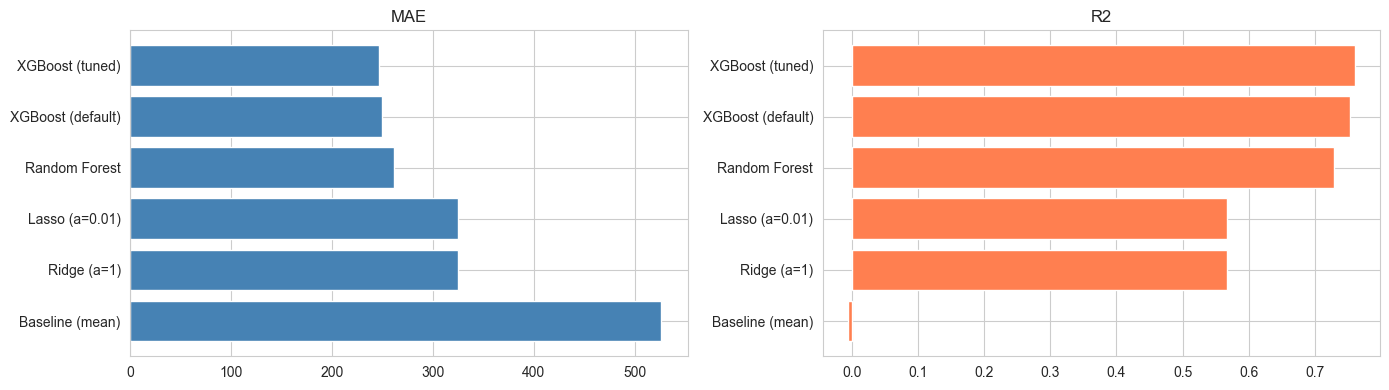

In [23]:
pipe_xgb_final = Pipeline([('prep', preprocessor), ('model', xgb.XGBRegressor(
    **study.best_params, n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist'))])
pipe_xgb_final.fit(X_train, y_train)
y_pred_xgb = pipe_xgb_final.predict(X_test)
report("XGBoost (tuned)", y_test, y_pred_xgb, results)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(results_df['model'], results_df['MAE'], color='steelblue'); axes[0].set_title('MAE')
axes[1].barh(results_df['model'], results_df['R2'], color='coral'); axes[1].set_title('R2')
plt.tight_layout(); plt.show()

## 11. Feature importance (terreno / anticipazione / cinematica)

Senza `EngineType` a fare da scorciatoia, emergono le feature vere. Coloriamo per famiglia:
**terreno** (slope/dz/climb/descent), **anticipazione** (`entry_*`/`next_*`), **cinematica/contesto**.

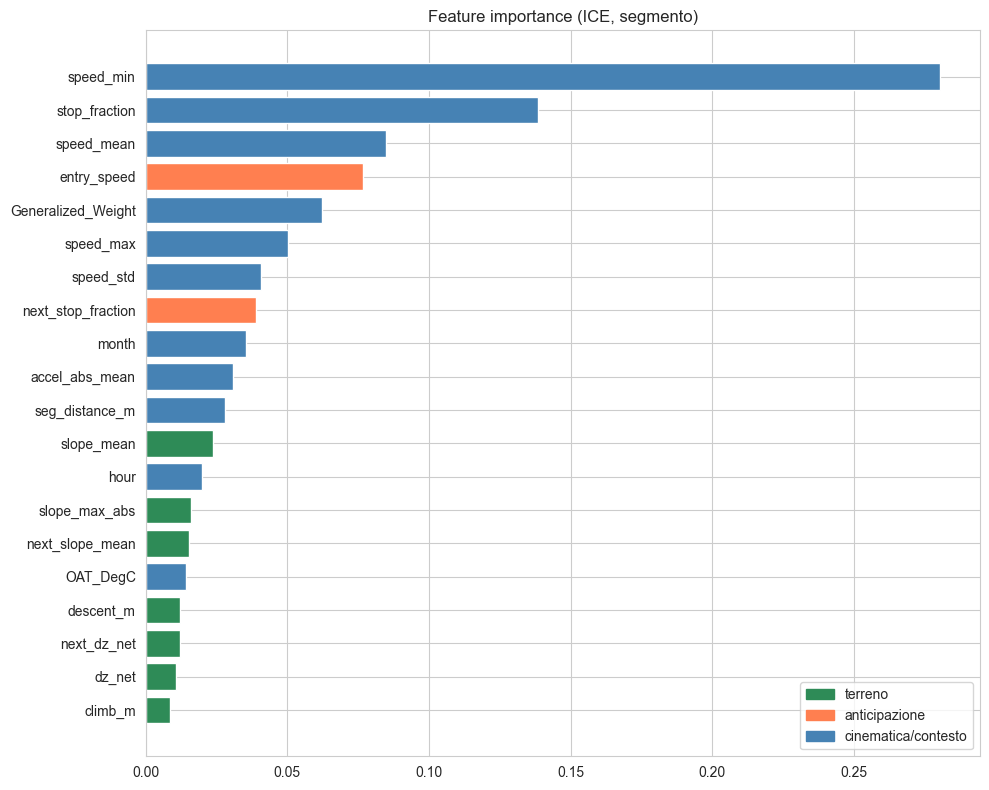

Peso TERRENO: 0.099 | ANTICIPAZIONE: 0.116
           feature  importance
         speed_min    0.280491
     stop_fraction    0.138500
        speed_mean    0.085012
       entry_speed    0.076644
Generalized_Weight    0.062101
         speed_max    0.050305
         speed_std    0.040687
next_stop_fraction    0.039076
             month    0.035462
    accel_abs_mean    0.030835
    seg_distance_m    0.027972
        slope_mean    0.023868


In [24]:
model = pipe_xgb_final.named_steps['model']
imp = pd.DataFrame({'feature': FEATURES_NUM, 'importance': model.feature_importances_}).sort_values('importance')
def fam(f):
    if any(k in f for k in ['slope', 'dz', 'climb', 'descent']): return 'terreno'
    if f.startswith('next_') or f.startswith('entry_'):          return 'anticipazione'
    return 'cinematica/contesto'
cmap = {'terreno': 'seagreen', 'anticipazione': 'coral', 'cinematica/contesto': 'steelblue'}
colors = [cmap[fam(f)] for f in imp['feature']]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp['feature'], imp['importance'], color=colors)
handles = [plt.Rectangle((0,0),1,1,color=c) for c in cmap.values()]
ax.legend(handles, cmap.keys(), loc='lower right'); ax.set_title('Feature importance (ICE, segmento)')
plt.tight_layout(); plt.show()
terr = imp[imp['feature'].apply(lambda f: fam(f)=='terreno')]['importance'].sum()
anti = imp[imp['feature'].apply(lambda f: fam(f)=='anticipazione')]['importance'].sum()
print(f"Peso TERRENO: {terr:.3f} | ANTICIPAZIONE: {anti:.3f}")
print(imp.sort_values('importance', ascending=False).head(12).to_string(index=False))

## 12. Sensibilita' alla lunghezza del segmento

XGBoost default per `SEG_LEN` in {150, 250, 500} m: R2 e peso del terreno. Giustifica con i dati la
scelta di 250 m.

In [25]:
def quick_score(seg_len):
    s = add_coupling(build_segments(df, seg_len)).dropna(subset=FEATURES_NUM + [TARGET]).reset_index(drop=True)
    ts = s.groupby(['VehId','Trip'])['Datetime'].min().sort_values()
    ntr = int(len(ts)*0.8)
    tr_trips = set(zip(ts.iloc[:ntr].index.get_level_values(0), ts.iloc[:ntr].index.get_level_values(1)))
    m = np.array([k in tr_trips for k in zip(s['VehId'], s['Trip'])])
    pipe = Pipeline([('prep', preprocessor), ('model', xgb.XGBRegressor(
        n_estimators=400, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist'))])
    pipe.fit(s.loc[m, FEATURES_NUM], s.loc[m, TARGET])
    r2 = r2_score(s.loc[~m, TARGET], pipe.predict(s.loc[~m, FEATURES_NUM]))
    fi = pipe.named_steps['model'].feature_importances_
    terr = sum(v for f, v in zip(FEATURES_NUM, fi) if any(k in f for k in ['slope','dz','climb','descent']))
    return {'SEG_LEN': seg_len, 'n_segments': len(s), 'R2': round(r2,3), 'peso_terreno': round(float(terr),3)}

sens = pd.DataFrame([quick_score(L) for L in [150, 250, 500]])
print(sens.to_string(index=False))

 SEG_LEN  n_segments    R2  peso_terreno
     150      490548 0.755         0.088
     250      299655 0.750         0.082
     500      150129 0.743         0.100


## 13. Applicazione eco-driving — controfattuale eco/sport su una route

Su un trip reale (sequenza di segmenti) confrontiamo tre strategie sullo stesso percorso scalando
in modo coerente le feature di velocita' (la geometria resta fissa). **Limite:** scaling uniforme,
non ottimizzazione selettiva; e' controllo su un modello statistico, non simulazione fisica.

In [26]:
route_summary = test_df.groupby(['VehId', 'Trip']).agg(
    n_seg=('maf_per_km', 'size'), climb=('climb_m', 'sum'), speed=('speed_mean', 'mean')).reset_index()
cand = route_summary[(route_summary['n_seg'].between(8, 60)) & (route_summary['climb'] > 15) & (route_summary['speed'] > 20)]
veh_id, trip_id = cand.sample(n=1, random_state=RANDOM_STATE)[['VehId', 'Trip']].iloc[0]
veh_id, trip_id = int(veh_id), int(trip_id)
route = test_df[(test_df['VehId']==veh_id) & (test_df['Trip']==trip_id)].sort_values('seg_in_trip').reset_index(drop=True)
print(f"Route: VehId={veh_id} Trip={trip_id}, {len(route)} segmenti")

SPEED_COLS = ['speed_mean', 'speed_max', 'speed_min', 'speed_std', 'entry_speed', 'accel_abs_mean']
def scale_speed_seg(X, k):
    Xs = X.copy()
    for c in SPEED_COLS: Xs[c] = Xs[c] * k
    return Xs
X_route = route[FEATURES_NUM]
km = route['seg_distance_m'].values / 1000.0
pred_real  = pipe_xgb_final.predict(X_route)
pred_eco   = pipe_xgb_final.predict(scale_speed_seg(X_route, 0.9))
pred_sport = pipe_xgb_final.predict(scale_speed_seg(X_route, 1.1))
air_real, air_eco, air_sport = (pred_real*km).sum(), (pred_eco*km).sum(), (pred_sport*km).sum()
print(f"Aria totale route (g): Reale {air_real:.0f} | Eco {air_eco:.0f} ({(air_eco/air_real-1)*100:+.1f}%) | Sport {air_sport:.0f} ({(air_sport/air_real-1)*100:+.1f}%)")

Route: VehId=157 Trip=4339, 8 segmenti
Aria totale route (g): Reale 4083 | Eco 3773 (-7.6%) | Sport 4076 (-0.2%)


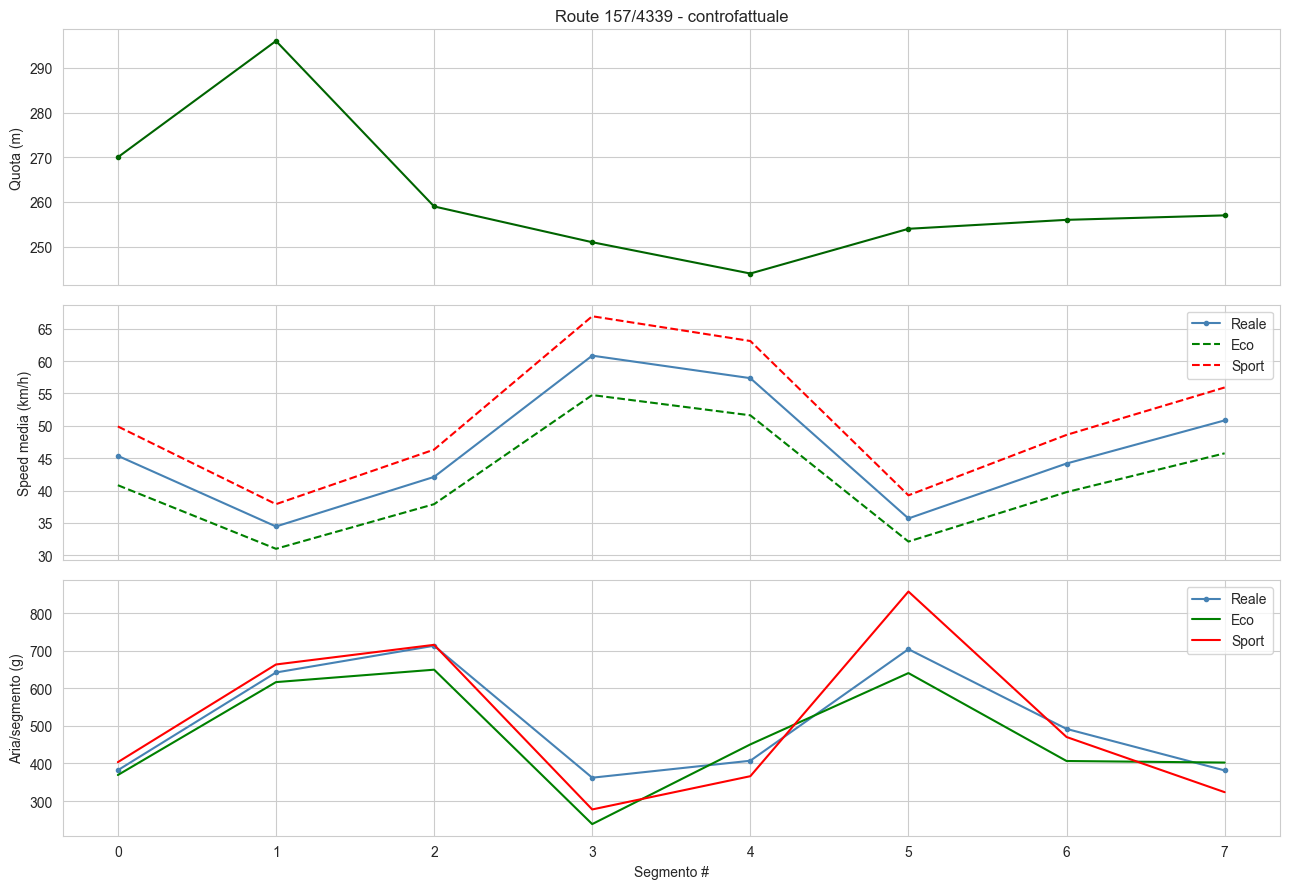

In [27]:
x = np.arange(len(route))
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(x, route['elev_start'], color='darkgreen', marker='o', ms=3); axes[0].set_ylabel('Quota (m)')
axes[0].set_title(f'Route {veh_id}/{trip_id} - controfattuale')
axes[1].plot(x, route['speed_mean'], label='Reale', color='steelblue', marker='o', ms=3)
axes[1].plot(x, route['speed_mean']*0.9, label='Eco', color='green', ls='--')
axes[1].plot(x, route['speed_mean']*1.1, label='Sport', color='red', ls='--')
axes[1].set_ylabel('Speed media (km/h)'); axes[1].legend()
axes[2].plot(x, pred_real*km, label='Reale', color='steelblue', marker='o', ms=3)
axes[2].plot(x, pred_eco*km, label='Eco', color='green'); axes[2].plot(x, pred_sport*km, label='Sport', color='red')
axes[2].set_ylabel('Aria/segmento (g)'); axes[2].set_xlabel('Segmento #'); axes[2].legend()
plt.tight_layout(); plt.show()

## 14. Diagnostica e salvataggio

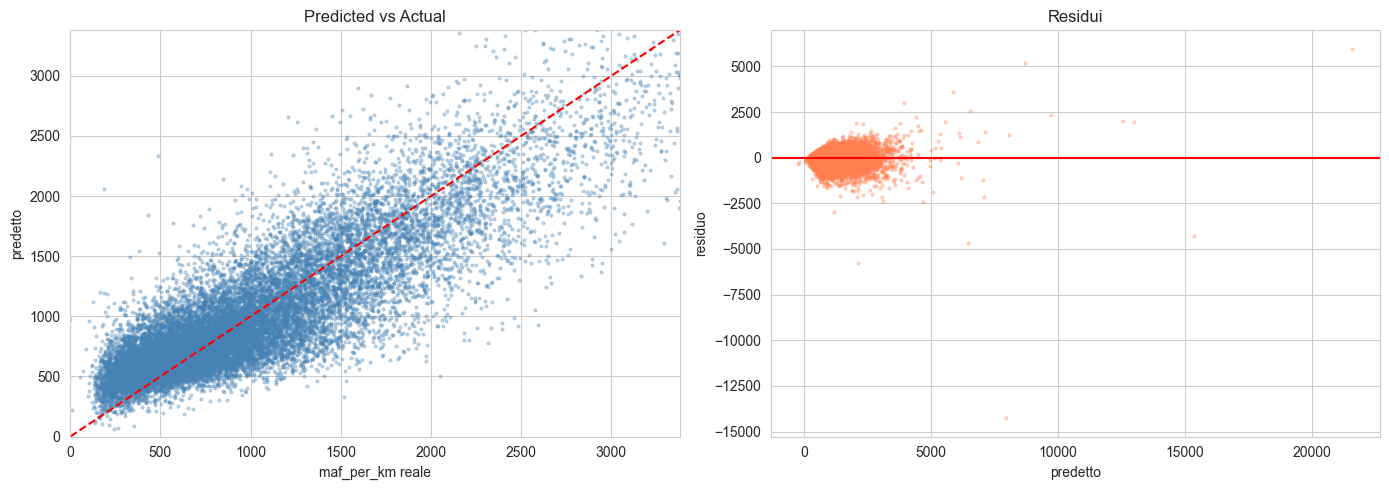

Salvati: consumption_model.joblib, consumption_results.csv, consumption_seglen_sensitivity.csv


In [28]:
idx = np.random.RandomState(RANDOM_STATE).choice(len(y_test), size=min(20000, len(y_test)), replace=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test.iloc[idx], y_pred_xgb[idx], s=4, alpha=0.3, color='steelblue')
lim = np.percentile(y_test, 99)
axes[0].plot([0, lim], [0, lim], 'r--'); axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel('maf_per_km reale'); axes[0].set_ylabel('predetto'); axes[0].set_title('Predicted vs Actual')
res = y_pred_xgb[idx] - y_test.iloc[idx].values
axes[1].scatter(y_pred_xgb[idx], res, s=4, alpha=0.3, color='coral'); axes[1].axhline(0, color='red')
axes[1].set_xlabel('predetto'); axes[1].set_ylabel('residuo'); axes[1].set_title('Residui')
plt.tight_layout(); plt.show()

import joblib
joblib.dump(pipe_xgb_final, "./outputs/consumption_model.joblib")
results_df.to_csv("./outputs/consumption_results.csv", index=False)
sens.to_csv("./outputs/consumption_seglen_sensitivity.csv", index=False)
print("Salvati: consumption_model.joblib, consumption_results.csv, consumption_seglen_sensitivity.csv")

---
## Riepilogo

- Modello di consumo **a segmento** (`maf_per_km`), **solo ICE** (dove MAF e' un proxy valido).
- Superato il target istantaneo (tautologico): qui contano profilo di velocita' anticipato,
  stop-and-go e geometria.
- **Terreno** verificato debole anche col dislivello cumulato e a tutte le lunghezze di segmento
  (limite del dato: Ann Arbor piatta + quantizzazione elevation ~111 m).
- Controfattuale eco/sport: scaling uniforme su modello statistico (non simulazione fisica).
- HEV/PHEV non sono qui (MAF non valido per loro): confronto powertrain nel NB3.